In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.version)
#Apparently we need 3.9 or higher Python version to run Multivelo

3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]


In [3]:
import scvelo as scv
import multivelo as mv

In [4]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)


In [5]:
os.chdir('/storage1/fs1/jmillman/Active/DigitalTwin')


# Preprocess Data

In [6]:
####Read in unspliced and spliced counts####
rna_data_s2d1 = sc.read("velocyto/output/VelocytoOutput_S2D1.loom", cache=True)
rna_data_s2d1.obs_names = ['s2d1_' + x.split(':')[1][:-1] for x in rna_data_s2d1.obs_names]
rna_data_s2d1.var_names_make_unique()

rna_data_s3d1 = sc.read("velocyto/output/VelocytoOutput_S3D1.loom", cache=True)
rna_data_s3d1.obs_names = ['s3d1_' + x.split(':')[1][:-1] for x in rna_data_s3d1.obs_names]
rna_data_s3d1.var_names_make_unique()

rna_data_s4d2 = sc.read("velocyto/output/VelocytoOutput_S4D2.loom", cache=True)
rna_data_s4d2.obs_names = ['s4d2_' + x.split(':')[1][:-1] for x in rna_data_s4d2.obs_names]
rna_data_s4d2.var_names_make_unique()

rna_data_s5d1 = sc.read("velocyto/output/VelocytoOutput_S5D1.loom", cache=True)
rna_data_s5d1.obs_names = ['s5d1_' + x.split(':')[1][:-1] for x in rna_data_s5d1.obs_names]
rna_data_s5d1.var_names_make_unique()

rna_data_s5d3 = sc.read("velocyto/output/VelocytoOutput_S5D3.loom", cache=True)
rna_data_s5d3.obs_names = ['s5d3_' + x.split(':')[1][:-1] for x in rna_data_s5d3.obs_names]
rna_data_s5d3.var_names_make_unique()

rna_data_s5d5 = sc.read("velocyto/output/VelocytoOutput_S5D5.loom", cache=True)
rna_data_s5d5.obs_names = ['s5d5_' + x.split(':')[1][:-1] for x in rna_data_s5d5.obs_names]
rna_data_s5d5.var_names_make_unique()

rna_data_s6d1 = sc.read("velocyto/output/VelocytoOutput_S6D1.loom", cache=True)
rna_data_s6d1.obs_names = ['s6d1_' + x.split(':')[1][:-1] for x in rna_data_s6d1.obs_names]
rna_data_s6d1.var_names_make_unique()

rna_data_s6d7 = sc.read("velocyto/output/VelocytoOutput_S6D7.loom", cache=True)
rna_data_s6d7.obs_names = ['s6d7_' + x.split(':')[1][:-1] for x in rna_data_s6d7.obs_names]
rna_data_s6d7.var_names_make_unique()

rna_data_s6d14 = sc.read("velocyto/output/VelocytoOutput_S6D14.loom", cache=True)
rna_data_s6d14.obs_names = ['s6d14_' + x.split(':')[1][:-1] for x in rna_data_s6d14.obs_names]
rna_data_s6d14.var_names_make_unique()

FileNotFoundError: Did not find file Multiome/MultiomeTimecourse/velocyto/output/VelocytoOutput_S2D1.loom.

In [ ]:
#Merge data
import anndata

rna_list = [
    rna_data_s2d1, rna_data_s3d1, rna_data_s4d2,
    rna_data_s5d1, rna_data_s5d3, rna_data_s5d5, 
    rna_data_s6d1, rna_data_s6d7, rna_data_s6d14 ]

for ad in rna_list:
    ad.var_names = ad.var_names.astype(str)  # peak IDs as strings
    for col in ad.var.columns:
        ad.var[col] = ad.var[col].astype(str)  # all var columns to strings
        
adata_rna = anndata.concat(
    rna_list,
    join="outer",          # keep all peaks
    merge="same",          # merge .obs/.var where identical
    label="batch",         # add a column in .obs to indicate batch
    keys=[
        "s2d1", "s3d1", "s4d2", 
        "s5d1", "s5d3", "s5d5", 
        "s6d1", "s6d7", "s6d14"
    ]
)


In [ ]:
# Save the result for use later on
adata_rna.write("checkpoints/MultiVelo/s2d1_s6d14_adata_rna.h5ad")


In [ ]:
adata_rna

In [ ]:
####Preprocess ATAC counts####
atac_data_s2d1 = sc.read_10x_mtx('10XData/Multiome/S2D1/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s2d1 = atac_data_s2d1[:,atac_data_s2d1.var['feature_types'] == "Peaks"]
atac_data_s2d1.obs_names = 's2d1_' + atac_data_s2d1.obs_names
atac_data_s2d1 = mv.aggregate_peaks_10x(atac_data_s2d1,
                                    '10XData/Multiome/S2D1/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S2D1/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s3d1 = sc.read_10x_mtx('10XData/Multiome/S3D1/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s3d1 = atac_data_s3d1[:,atac_data_s3d1.var['feature_types'] == "Peaks"]
atac_data_s3d1.obs_names = 's3d1_' + atac_data_s3d1.obs_names
atac_data_s3d1 = mv.aggregate_peaks_10x(atac_data_s3d1,
                                    '10XData/Multiome/S3D1/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S3D1/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s4d2 = sc.read_10x_mtx('10XData/Multiome/S4D2/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s4d2 = atac_data_s4d2[:,atac_data_s4d2.var['feature_types'] == "Peaks"]
atac_data_s4d2.obs_names = 's4d2_' + atac_data_s4d2.obs_names
atac_data_s4d2 = mv.aggregate_peaks_10x(atac_data_s4d2,
                                    '10XData/Multiome/S4D2/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S4D2/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s5d1 = sc.read_10x_mtx('10XData/Multiome/S5D1/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s5d1 = atac_data_s5d1[:,atac_data_s5d1.var['feature_types'] == "Peaks"]
atac_data_s5d1.obs_names = 's5d1_' + atac_data_s5d1.obs_names
atac_data_s5d1 = mv.aggregate_peaks_10x(atac_data_s5d1,
                                    '10XData/Multiome/S5D1/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S5D1/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s5d3 = sc.read_10x_mtx('10XData/Multiome/S5D3/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s5d3 = atac_data_s5d3[:,atac_data_s5d3.var['feature_types'] == "Peaks"]
atac_data_s5d3.obs_names = 's5d3_' + atac_data_s5d3.obs_names
atac_data_s5d3 = mv.aggregate_peaks_10x(atac_data_s5d3,
                                    '10XData/Multiome/S5D3/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S5D3/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s5d5 = sc.read_10x_mtx('10XData/Multiome/S5D5/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s5d5 = atac_data_s5d5[:,atac_data_s5d5.var['feature_types'] == "Peaks"]
atac_data_s5d5.obs_names = 's5d5_' + atac_data_s5d5.obs_names
atac_data_s5d5 = mv.aggregate_peaks_10x(atac_data_s5d5,
                                    '10XData/Multiome/S5D5/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S5D5/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s6d1 = sc.read_10x_mtx('10XData/Multiome/S6D1/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s6d1 = atac_data_s6d1[:,atac_data_s6d1.var['feature_types'] == "Peaks"]
atac_data_s6d1.obs_names = 's6d1_' + atac_data_s6d1.obs_names
atac_data_s6d1 = mv.aggregate_peaks_10x(atac_data_s6d1,
                                    '10XData/Multiome/S6D1/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S6D1/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s6d7 = sc.read_10x_mtx('10XData/Multiome/S6D7/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s6d7 = atac_data_s6d7[:,atac_data_s6d7.var['feature_types'] == "Peaks"]
atac_data_s6d7.obs_names = 's6d7_' + atac_data_s6d7.obs_names
atac_data_s6d7 = mv.aggregate_peaks_10x(atac_data_s6d7,
                                    '10XData/Multiome/S6D7/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S6D7/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

atac_data_s6d14 = sc.read_10x_mtx('10XData/Multiome/S6D14/outs/filtered_feature_bc_matrix/', var_names='gene_symbols', cache=True, gex_only=False)
atac_data_s6d14 = atac_data_s6d14[:,atac_data_s6d14.var['feature_types'] == "Peaks"]
atac_data_s6d14.obs_names = 's6d14_' + atac_data_s6d14.obs_names
atac_data_s6d14 = mv.aggregate_peaks_10x(atac_data_s6d14,
                                    '10XData/Multiome/S6D14/outs/atac_peak_annotation.tsv',
                                    '10XData/Multiome/S6D14/outs/analysis/feature_linkage/feature_linkage.bedpe',
                                    verbose=True)

In [ ]:
atac_data_s2d1

In [ ]:
#Merge data
import anndata

atac_list = [
    atac_data_s2d1, atac_data_s3d1, atac_data_s4d2,
    atac_data_s5d1, atac_data_s5d3, atac_data_s5d5,
    atac_data_s6d1, atac_data_s6d7, atac_data_s6d14
]

for ad in atac_list:
    ad.var_names = ad.var_names.astype(str)  # peak IDs as strings
    for col in ad.var.columns:
        ad.var[col] = ad.var[col].astype(str)  # all var columns to strings
        
adata_atac = anndata.concat(
    atac_list,
    join="outer",          # keep all peaks
    merge="same",          # merge .obs/.var where identical
    label="batch",         # add a column in .obs to indicate batch
    keys=[
        "s2d1", "s3d1", "s4d2", "s5d1",
        "s5d3", "s5d5", "s6d1", "s6d7", "s6d14"
    ]
)


In [ ]:
adata_atac

In [ ]:
# Save the result for use later on
adata_atac.write("checkpoints/MultiVelo/s2d1_s6d14_adata_atac.h5ad")


# MultioVelo Pipeline

In [6]:
os.getcwd()

'/storage1/fs1/jmillman/Active/DigitalTwin'

In [7]:
# We reload in the raw data
adata_rna = sc.read_h5ad("checkpoints/MultiVelo/s2d1_s6d14_adata_rna.h5ad")

In [8]:
adata_atac = sc.read_h5ad("checkpoints/MultiVelo/s2d1_s6d14_adata_atac.h5ad")

In [9]:
len(adata_rna.var_names)

58395

In [13]:
len(adata_atac.var_names)

25773

In [14]:
shared_cells = pd.read_csv("checkpoints/MultiVelo/seurat_wnn/combined_barcodes.csv", header=None)[0]

#shared_cells

In [15]:
#adata_rna.obs_names

In [16]:
adata_rna.obs_names = adata_rna.obs_names + '-1'
#adata_rna.obs_names

In [17]:
valid_cells = shared_cells[shared_cells.isin(adata_rna.obs_names)]
#valid_cells

In [18]:
#Check the layers of the adata_rna, if they have the spliced/unspliced
#print(adata_rna.layers.keys())


In [19]:
pip install --user scikit-misc

Note: you may need to restart the kernel to use updated packages.


In [20]:
import numpy as np
import pandas as pd
import scvelo as scv
import scanpy as sc

# --- INPUTS ---
# adata_raw: your original AnnData (with full expression, layers, etc.)
# must_keep: iterable of ~200 gene names you want to force include
must_keep = set(['ABCC8', 'ACOX2', 'ACSS1', 'ACSS3', 'AFP', 'AHR', 'ALDOA', 'ALX1',
                 'ALX3', 'AR', 'ARHGEF12', 'ARID2', 'ARID5B', 'ARNT2', 'ARX', 'ASCL1',
                 'ASCL2', 'ATF2', 'ATF6', 'ATP5MC3', 'ATP6V0E1', 'BACH1', 'BACH2',
                 'BARX2', 'BBX', 'BCL11A', 'BCLAF1', 'BDP1', 'BMP4', 'BPTF',
                 'CACNA1A', 'CACNA1B', 'CACNA1C', 'CACNA1E', 'CA2', 'CBX5', 'CCDC6',
                 'CDH1', 'CDH2', 'CDX2', 'CER1', 'CFTR', 'CHD2', 'CHGA', 'CHGB', 'CLOCK',
                 'CMIP', 'COL1A1', 'COL3A1', 'COX4I1', 'CREB1', 'CREB3L2', 'CREB5',
                 'CTCF', 'CTNNB1', 'CUX1', 'CUX2', 'DDC', 'DLL3', 'DMRT3', 'DPP4',
                 'E2F3', 'E2F7', 'EBF1', 'EBF3', 'ELF1', 'ELF2', 'EN1', 'ENO1',
                 'EPAS1', 'ERG', 'ERO1B', 'ESR1', 'ESR2', 'ESRRB', 'ESRRG', 'ETS1',
                 'ETS2', 'ETV1', 'ETV6', 'FEV', 'FFAR1', 'FGF10', 'FGF4', 'FGF8',
                 'FOXA1', 'FOXA2', 'FOXA3', 'FOXC1', 'FOXJ3', 'FOXN2', 'FOXN3',
                 'FOXO1', 'FOXO3', 'FOXP1', 'FOXP2', 'FOXP3', 'GAST', 'GATA2',
                 'GATA4', 'GATA6', 'GCH1', 'GCK', 'GCG', 'GH1', 'GHRL', 'GIP', 'GLI2',
                 'GLI3', 'GLIS3', 'GPI', 'GRHL2', 'GTF2I', 'HCN1', 'HCN2', 'HCN3',
                 'HCN4', 'HDAC2', 'HDX', 'HES1', 'HESX1', 'HHEX', 'HIF1A', 'HIVEP1',
                 'HIVEP2', 'HIVEP3', 'HLTF', 'HMGA2', 'HNF1A', 'HNF1B', 'HNF4A',
                 'HNF4G', 'HTR1A', 'HTR2A', 'HTR3A', 'HTR4', 'IAPP', 'ID1', 'ID2',
                 'IGF1', 'IGF2', 'IKZF2', 'INS', 'INSM1', 'IRX1', 'IRX2', 'ISL1',
                 'ISX', 'JUN', 'KCNA3', 'KCNA6', 'KCNC2', 'KCNC4', 'KCNG4', 'KCNH2',
                 'KCNJ11', 'KCNJ2', 'KCNJ4', 'KCNJ6', 'KCNK1', 'KCNK12', 'KCNK17',
                 'KCNMA1', 'KCNMB2', 'KCNN1', 'KLF12', 'KLF5', 'KLF7', 'KRT19', 'KRT7',
                 'LHX1', 'LHX3', 'LHX4', 'LHX6', 'LMO2', 'LMX1A', 'LMX1B', 'MAF',
                 'MAFA', 'MAFB', 'MAOA', 'MAOB', 'MAP3K11', 'MECOM', 'MEF2A', 'MEF2C',
                 'MEIS1', 'MEIS2', 'MITF', 'MKI67', 'MLXIPL', 'MMP2', 'MNX1', 'MXI1',
                 'MYCN', 'MYEF2', 'MYT1', 'NANOG', 'NF1', 'NFAT5', 'NFATC2', 'NFATC3',
                 'NFIA', 'NFIB', 'NFKB1', 'NEUROD1', 'NEUROD4', 'NEUROG3', 'NKX2-1',
                 'NKX2-2', 'NKX2-5', 'NKX3-2', 'NKX6-1', 'NKX6-2', 'NKX6-3', 'NNT', 
                 'NOTO', 'NPAS3', 'NR0B1', 'NR0B2', 'NR2C2', 'NR3C1', 'NR3C2', 'NR4A3',
                 'NR5A1', 'NR5A2', 'NR6A1', 'NRF1', 'ONECUT1', 'ONECUT2', 'ONECUT3',
                 'OSR1', 'OTX2', 'PAX1', 'PAX2', 'PAX3', 'PAX4', 'PAX6', 'PBX1',
                 'PBX3', 'PCSK1', 'PDIA6', 'PDX1', 'PGAP1', 'PHOX2A', 'PITX1', 'PITX2',
                 'PLAG1', 'PLAGL1', 'POU1F1', 'POU2F1', 'POU2F2', 'POU3F4', 'POU5F1',
                 'POU6F2', 'PPARG', 'PPY', 'PRDM14', 'PRDM16', 'PRDM5', 'PRKCSH', 'PRLR',
                 'PROP1', 'PROX1', 'PTEN', 'PYY', 'RAD21', 'RAP1A', 'RBPJ', 'RFX1',
                 'RFX2', 'RFX3', 'RFX4', 'RFX6', 'RFX7', 'RIMS1', 'RIMS2', 'RIMS4',
                 'RORA', 'RORB', 'RREB1', 'RUNX1', 'RXRA', 'RXRB', 'RXRG', 'SCN1A',
                 'SCN2A', 'SCN3A', 'SCN4A', 'SCT', 'SHH', 'SIM1', 'SIX2', 'SLC18A1',
                 'SLC2A1', 'SLC2A14', 'SLC2A2', 'SLC2A3', 'SLC30A8', 'SLC6A4', 'SMAD2',
                 'SMAD3', 'SMARCA1', 'SMARCA5', 'SMARCC1', 'SMC3', 'SNAI1', 'SNAI2',
                 'SNAP25', 'SOX11', 'SOX17', 'SOX2', 'SOX4', 'SOX6', 'SOX9', 'SP8',
                 'SPINK1', 'SREBF2', 'SRY', 'SST', 'SSTR2', 'STAT1', 'STAT4', 'STX1A',
                 'STXBP1', 'SYP', 'SYT4', 'SYT7', 'SYT8', 'TBX3', 'TBX5', 'TCF12', 'TCF4', 
                 'TCF7L1', 'TCF7L2', 'TEAD1', 'TFDP2', 'THRA', 'THRB', 'TOP2A', 'TP63', 
                 'TPH1', 'TPH2', 'UCN3', 'UNCX', 'VAMP2', 'WNT11', 'WNT2', 'WNT4', 'WNT5A', 
                 'WNT7B', 'XBP1', 'ZBTB16', 'ZBTB7C', 'ZEB1', 'ZFHX3', 'ZKSCAN1', 'ZNF148', 
                 'ZNF423', 'ZNF431', 'ZNF652', 'ZNF708'
                     ])  # put your genes here

# --- 1) Normalize WITHOUT dropping genes (preserve full info) ---
# If scv.pp.filter_and_normalize requires an int for n_top_genes, use total number of genes to avoid subsetting.
adata_proc = scv.pp.filter_and_normalize(
    adata_rna,
    min_shared_counts=1,
    n_top_genes=adata_rna.n_vars,  # keeps all genes
    copy=True
)

# --- 2) Rank HVGs across ALL genes (keeps full matrix) ---
# You can change flavor if you prefer. seurat_v3 is common.
sc.pp.highly_variable_genes(
    adata_proc,
    n_top_genes=5000,
    flavor="seurat_v3",
    inplace=True
)
# Boolean mask of the initial 5,000 HVGs
hvg_mask = adata_proc.var["highly_variable"].fillna(False).astype(bool)
hvg_genes = set(adata_proc.var_names[hvg_mask])

# --- 3) Force include must-keep genes that actually exist ---
all_genes = set(adata_proc.var_names)
must_keep_in_data = must_keep & all_genes
missing = must_keep - all_genes
if missing:
    print(f"Warning: {len(missing)} must-keep genes not found and will be ignored.")

# Genes to add beyond the 5k HVGs
extra = list(must_keep_in_data - hvg_genes)

# --- 4) Cap at 5,500 by trimming lowest-variance HVGs (not the must-keep set) ---
cap = 5500
overflow = max(0, len(hvg_genes) + len(extra) - cap)

if overflow > 0:
    var_df = adata_proc.var.copy()
    # Prefer normalized dispersion if present; fallback to raw dispersion; else fallback to HVG ranks
    score_col = "dispersions_norm" if "dispersions_norm" in var_df.columns else (
        "dispersions" if "dispersions" in var_df.columns else None
    )

    hvg_only = list(hvg_genes)  # only HVGs are candidates for dropping
    if score_col is not None:
        # Sort ascending: lowest variance first
        low_var_order = var_df.loc[hvg_only, score_col].sort_values(ascending=True).index.tolist()
        to_drop = set(low_var_order[:overflow])
    else:
        # Use HVG rank if available
        if "highly_variable_rank" in var_df.columns:
            low_rank_order = var_df.loc[hvg_only, "highly_variable_rank"].sort_values(ascending=False).index.tolist()
            # (higher rank number is "worse"—take the worst)
            to_drop = set(low_rank_order[:overflow])
        else:
            # Last resort: arbitrary trim
            print("Note: No dispersion or rank columns found; trimming HVGs by arbitrary order as fallback.")
            to_drop = set(hvg_only[:overflow])

    hvg_genes -= to_drop

# --- 5) Build final active gene set (≤ 5,500), preserve full matrix ---
final_set = list(hvg_genes) + [g for g in adata_proc.var_names if g in extra]
# Deduplicate and re-check membership (belt & suspenders)
final_set = [g for i, g in enumerate(final_set) if g in all_genes and g not in set(final_set[:i])]
assert len(final_set) <= cap, "Final gene list exceeds the 5,500 cap unexpectedly."

# --- 6) Store a flag instead of subsetting (keeps ALL data intact) ---
adata_proc.var["keep5500"] = adata_proc.var_names.isin(final_set)

print(
    f"keep5500=True: {adata_proc.var['keep5500'].sum()} | "
    f"HVG base: {np.sum(hvg_mask)} | "
    f"Must-keep added: {len([g for g in extra if g in final_set])} | "
    f"Missing must-keep (ignored): {len(missing)}"
)

# --- USAGE EXAMPLES ---
# When you actually need the reduced view for a step:
# adata_work = adata_proc[:, adata_proc.var["keep5500"]].copy()
# (This preserves all layers/obs/obsm in the copy, while adata_proc retains EVERYTHING.)


Filtered out 37536 genes that are detected 1 counts (shared).
Normalized count data: X, spliced, unspliced.
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.


/opt/conda/envs/scvelo/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


keep5500=True: 5219 | HVG base: 5000 | Must-keep added: 219 | Missing must-keep (ignored): 27


In [21]:
'''
['ABCC8', 'ACOX2', 'ACSS1', 'ACSS3', 'AFP', 'AHR', 'ALDOA', 'ALX1',
                 'ALX3', 'AR', 'ARHGEF12', 'ARID2', 'ARID5B', 'ARNT2', 'ARX', 'ASCL1',
                 'ASCL2', 'ATF2', 'ATF6', 'ATP5MC3', 'ATP6V0E1', 'BACH1', 'BACH2',
                 'BARX2', 'BBX', 'BCL11A', 'BCLAF1', 'BDP1', 'BMP4', 'BPTF',
                 'CACNA1A', 'CACNA1B', 'CACNA1C', 'CACNA1E', 'CA2', 'CBX5', 'CCDC6',
                 'CDH1', 'CDH2', 'CDX2', 'CER1','CFTR', 'CHD2', 'CHGA', 'CHGB', 'CLOCK',
                 'CMIP', 'COL1A1', 'COL3A1', 'COX4I1', 'CREB1', 'CREB3L2', 'CREB5',
                 'CTCF', 'CTNNB1', 'CUX1', 'CUX2', 'DDC', 'DLL3', 'DMRT3', 'DPP4',
                 'E2F3', 'E2F7', 'EBF1', 'EBF3', 'ELF1', 'ELF2', 'EN1', 'ENO1',
                 'EPAS1', 'ERG', 'ERO1B', 'ESR1', 'ESR2', 'ESRRB', 'ESRRG', 'ETS1',
                 'ETS2', 'ETV1', 'ETV6', 'FEV', 'FFAR1', 'FGF10', 'FGF4', 'FGF8',
                 'FOXA1', 'FOXA2', 'FOXA3', 'FOXC1', 'FOXJ3', 'FOXN2', 'FOXN3',
                 'FOXO1', 'FOXO3', 'FOXP1', 'FOXP2', 'FOXP3', 'GAST', 'GATA2',
                 'GATA4', 'GATA6', 'GCH1', 'GCK', 'GCG', 'GH1', 'GHRL', 'GIP', 'GLI2',
                 'GLI3', 'GLIS3', 'GPI', 'GRHL2', 'GTF2I', 'HCN1', 'HCN2', 'HCN3',
                 'HCN4', 'HDAC2', 'HDX', 'HES1', 'HESX1', 'HHEX', 'HIF1A', 'HIVEP1',
                 'HIVEP2', 'HIVEP3', 'HLTF', 'HMGA2', 'HNF1A', 'HNF1B', 'HNF4A',
                 'HNF4G', 'HTR1A', 'HTR2A', 'HTR3A', 'HTR4', 'IAPP', 'ID1', 'ID2',
                 'IGF1', 'IGF2', 'IKZF2', 'INS', 'INSM1', 'IRX1', 'IRX2', 'ISL1',
                 'ISX', 'JUN', 'KCNA3', 'KCNA6', 'KCNC2', 'KCNC4', 'KCNG4', 'KCNH2',
                 'KCNJ11', 'KCNJ2', 'KCNJ4', 'KCNJ6', 'KCNK1', 'KCNK12', 'KCNK17',
                 'KCNMA1', 'KCNMB2', 'KCNN1', 'KLF12', 'KLF5', 'KLF7', 'KRT19', 'KRT7',
                 'LHX1', 'LHX3', 'LHX4', 'LHX6', 'LMO2', 'LMX1A', 'LMX1B', 'MAF',
                 'MAFA', 'MAFB', 'MAOA', 'MAOB', 'MAP3K11', 'MECOM', 'MEF2A', 'MEF2C',
                 'MEIS1', 'MEIS2', 'MITF', 'MKI67', 'MLXIPL', 'MMP2', 'MNX1', 'MXI1',
                 'MYCN', 'MYEF2', 'MYT1', 'NANOG', 'NF1', 'NFAT5', 'NFATC2', 'NFATC3',
                 'NFIA', 'NFIB', 'NFKB1', 'NEUROD1', 'NEUROD4', 'NEUROG3', 'NKX2-1',
                 'NKX2-2', 'NKX2-5', 'NKX3-2', 'NKX6-1', 'NKX6-2', 'NKX6-3', 'NNT', 
                 'NOTO', 'NPAS3', 'NR0B1', 'NR0B2', 'NR2C2', 'NR3C1', 'NR3C2', 'NR4A3',
                 'NR5A1', 'NR5A2', 'NR6A1', 'NRF1', 'ONECUT1', 'ONECUT2', 'ONECUT3',
                 'OSR1', 'OTX2', 'PAX1', 'PAX2', 'PAX3', 'PAX4', 'PAX6', 'PBX1',
                 'PBX3', 'PCSK1', 'PDIA6', 'PDX1', 'PGAP1', 'PHOX2A', 'PITX1', 'PITX2',
                 'PLAG1', 'PLAGL1', 'POU1F1', 'POU2F1', 'POU2F2', 'POU3F4', 'POU5F1',
                 'POU6F2', 'PPARG', 'PPY', 'PRDM14', 'PRDM16', 'PRDM5', 'PRKCSH', 'PRLR',
                 'PROP1', 'PROX1', 'PTEN', 'PYY', 'RAD21', 'RAP1A', 'RBPJ', 'RFX1',
                 'RFX2', 'RFX3', 'RFX4', 'RFX6', 'RFX7', 'RIMS1', 'RIMS2', 'RIMS4',
                 'RORA', 'RORB', 'RREB1', 'RUNX1', 'RXRA', 'RXRB', 'RXRG', 'SCN1A',
                 'SCN2A', 'SCN3A', 'SCN4A', 'SCT', 'SHH', 'SIM1', 'SIX2', 'SLC18A1',
                 'SLC2A1', 'SLC2A14', 'SLC2A2', 'SLC2A3', 'SLC30A8', 'SLC6A4', 'SMAD2',
                 'SMAD3', 'SMARCA1', 'SMARCA5', 'SMARCC1', 'SMC3', 'SNAI1', 'SNAI2',
                 'SNAP25', 'SOX11', 'SOX17', 'SOX2', 'SOX4', 'SOX6', 'SOX9', 'SP8',
                 'SPINK1', 'SREBF2', 'SRY', 'SST', 'SSTR2', 'STAT1', 'STAT4', 'STX1A',
                 'STXBP1', 'SYP', 'SYT4', 'SYT7', 'SYT8', 'TBX3', 'TBX5', 'TCF12', 'TCF4', 
                 'TCF7L1', 'TCF7L2', 'TEAD1', 'TFDP2', 'THRA', 'THRB', 'TOP2A', 'TP63', 
                 'TPH1', 'TPH2', 'UCN3', 'UNCX', 'VAMP2', 'WNT11', 'WNT2', 'WNT4', 'WNT5A', 
                 'WNT7B', 'XBP1', 'ZBTB16', 'ZBTB7C', 'ZEB1', 'ZFHX3', 'ZKSCAN1', 'ZNF148', 
                 'ZNF423', 'ZNF431', 'ZNF652', 'ZNF708'
                     ])
                     
            
'''

"\n['ABCC8', 'ACOX2', 'ACSS1', 'ACSS3', 'AFP', 'AHR', 'ALDOA', 'ALX1',\n                 'ALX3', 'AR', 'ARHGEF12', 'ARID2', 'ARID5B', 'ARNT2', 'ARX', 'ASCL1',\n                 'ASCL2', 'ATF2', 'ATF6', 'ATP5MC3', 'ATP6V0E1', 'BACH1', 'BACH2',\n                 'BARX2', 'BBX', 'BCL11A', 'BCLAF1', 'BDP1', 'BMP4', 'BPTF',\n                 'CACNA1A', 'CACNA1B', 'CACNA1C', 'CACNA1E', 'CA2', 'CBX5', 'CCDC6',\n                 'CDH1', 'CDH2', 'CDX2', 'CER1','CFTR', 'CHD2', 'CHGA', 'CHGB', 'CLOCK',\n                 'CMIP', 'COL1A1', 'COL3A1', 'COX4I1', 'CREB1', 'CREB3L2', 'CREB5',\n                 'CTCF', 'CTNNB1', 'CUX1', 'CUX2', 'DDC', 'DLL3', 'DMRT3', 'DPP4',\n                 'E2F3', 'E2F7', 'EBF1', 'EBF3', 'ELF1', 'ELF2', 'EN1', 'ENO1',\n                 'EPAS1', 'ERG', 'ERO1B', 'ESR1', 'ESR2', 'ESRRB', 'ESRRG', 'ETS1',\n                 'ETS2', 'ETV1', 'ETV6', 'FEV', 'FFAR1', 'FGF10', 'FGF4', 'FGF8',\n                 'FOXA1', 'FOXA2', 'FOXA3', 'FOXC1', 'FOXJ3', 'FOXN2', 'FOXN3',\n   

In [22]:
adata_proc

AnnData object with n_obs × n_vars = 88697 × 20859
    obs: 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'keep5500'
    uns: 'log1p', 'hvg'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [23]:
adata_work = adata_proc[:, adata_proc.var_names.isin(final_set)].copy()
print(len(adata_work.var_names))  # should be <= len(must_keep or final_set, depending on what do you want)


5219


In [24]:
adata_work

AnnData object with n_obs × n_vars = 88697 × 5219
    obs: 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'keep5500'
    uns: 'log1p', 'hvg'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [25]:
adata_atac

AnnData object with n_obs × n_vars = 88697 × 25773
    obs: 'batch'

In [26]:
shared_genes = pd.Index(np.intersect1d(adata_work.var_names, adata_atac.var_names))

In [27]:
len(shared_genes)  # <= 5500


3860

In [28]:
adata_rna

AnnData object with n_obs × n_vars = 88697 × 58395
    obs: 'batch'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [29]:
adata_rna = adata_work

In [30]:
adata_work.obs_names

Index(['s2d1_AAACCGGCACACAATT-1', 's2d1_AAACCAACACTGACTA-1',
       's2d1_AAACGTACAGGAACAT-1', 's2d1_AAACCGGCACCTGCTC-1',
       's2d1_AAACGCGCATTTGCTC-1', 's2d1_AAACGGATCAAAGGCA-1',
       's2d1_AAACGGATCATCCACC-1', 's2d1_AAACGGATCCGTTATT-1',
       's2d1_AAACCAACAACAGCCT-1', 's2d1_AAACATGCAATAGCCC-1',
       ...
       's6d14_TTTGTGAAGCTTGCTC-1', 's6d14_TTTGTGTTCATAACTG-1',
       's6d14_TTTGTTGGTCCTCCAA-1', 's6d14_TTTGTTGGTCCCGAAG-1',
       's6d14_TTTGTGAAGTCTTGAA-1', 's6d14_TTTGTTGGTAATCGCA-1',
       's6d14_TTTGTGTTCCTAATGA-1', 's6d14_TTTGTTGGTTATCGAG-1',
       's6d14_TTTGTGAAGTTAGTGC-1', 's6d14_TTTGTTGGTTGTTGGA-1'],
      dtype='object', length=88697)

In [31]:
adata_rna

AnnData object with n_obs × n_vars = 88697 × 5219
    obs: 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'keep5500'
    uns: 'log1p', 'hvg'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [32]:
# Now subset
#adata_rna.obs_names = adata_rna.obs_names + '-1'
adata_rna.obs_names

adata_rna = adata_rna[valid_cells, shared_genes]
adata_atac = adata_atac[valid_cells, shared_genes]

In [33]:
adata_rna.obs_names 

Index(['s2d1_AAACAGCCAAAGCGCA-1', 's2d1_AAACAGCCACATGCTA-1',
       's2d1_AAACAGCCAGCTAATT-1', 's2d1_AAACAGCCAGGACCTT-1',
       's2d1_AAACAGCCAGGCGATA-1', 's2d1_AAACAGCCAGGCTAAG-1',
       's2d1_AAACAGCCAGTAGCCT-1', 's2d1_AAACAGCCATGGAGGC-1',
       's2d1_AAACAGCCATTGCGAC-1', 's2d1_AAACATGCAATAGCCC-1',
       ...
       's6d14_TTTGTTGGTCCTCCAA-1', 's6d14_TTTGTTGGTGCAACTA-1',
       's6d14_TTTGTTGGTGGACATC-1', 's6d14_TTTGTTGGTGTTAGCA-1',
       's6d14_TTTGTTGGTTATCGAG-1', 's6d14_TTTGTTGGTTCATCTA-1',
       's6d14_TTTGTTGGTTGCCTCA-1', 's6d14_TTTGTTGGTTGTTGGA-1',
       's6d14_TTTGTTGGTTTACGTC-1', 's6d14_TTTGTTGGTTTGGGCG-1'],
      dtype='object', length=69535)

In [34]:
adata_atac.obs_names

Index(['s2d1_AAACAGCCAAAGCGCA-1', 's2d1_AAACAGCCACATGCTA-1',
       's2d1_AAACAGCCAGCTAATT-1', 's2d1_AAACAGCCAGGACCTT-1',
       's2d1_AAACAGCCAGGCGATA-1', 's2d1_AAACAGCCAGGCTAAG-1',
       's2d1_AAACAGCCAGTAGCCT-1', 's2d1_AAACAGCCATGGAGGC-1',
       's2d1_AAACAGCCATTGCGAC-1', 's2d1_AAACATGCAATAGCCC-1',
       ...
       's6d14_TTTGTTGGTCCTCCAA-1', 's6d14_TTTGTTGGTGCAACTA-1',
       's6d14_TTTGTTGGTGGACATC-1', 's6d14_TTTGTTGGTGTTAGCA-1',
       's6d14_TTTGTTGGTTATCGAG-1', 's6d14_TTTGTTGGTTCATCTA-1',
       's6d14_TTTGTTGGTTGCCTCA-1', 's6d14_TTTGTTGGTTGTTGGA-1',
       's6d14_TTTGTTGGTTTACGTC-1', 's6d14_TTTGTTGGTTTGGGCG-1'],
      dtype='object', length=69535)

In [35]:
dataset = pd.read_csv("checkpoints/MultiVelo/seurat_wnn/combined_dataset.csv", sep=",", index_col=0, header=None)
dataset.columns = ["stage"]  # rename the only column to "stage"
adata_rna.obs['stage'] = dataset['stage']
adata_rna.obs['stage'] = adata_rna.obs['stage'].astype('category')

In [37]:
# Read in Seurat WNN neighbors.
nn_idx = np.loadtxt("checkpoints/MultiVelo/seurat_wnn/combined_nn_idx.txt", delimiter=',')
nn_dist = np.loadtxt("checkpoints/MultiVelo/seurat_wnn/combined_nn_dist.txt", delimiter=',')
nn_cells = pd.Index(pd.read_csv("checkpoints/MultiVelo/seurat_wnn/combined_nn_cells.txt", header=None)[0])

# Make sure cell names match.
np.all(nn_cells == adata_atac.obs_names)

True

In [38]:
# Smoothing gene aggregagted peaks by neighbors
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)
adata_atac

AnnData object with n_obs × n_vars = 69535 × 3860
    obs: 'batch'
    layers: 'Mc'
    obsp: 'connectivities'

In [39]:
# load cell metadata:
cell_meta = pd.read_csv("checkpoints/MultiVelo/seurat_wnn/metadata.csv")

# set anndata observations and index obs by barcodes, var by gene names
adata_rna.obs = cell_meta
adata_rna

In [52]:
# set anndata observations and index obs by barcodes, var by gene names
adata_atac.obs = cell_meta
adata_atac

AnnData object with n_obs × n_vars = 69535 × 3860
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'dataset', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA.weight', 'peaks.weight', 'wnn_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'merged_rna_clusters', 'cca_clusters', 'rpca_clusters', 'harmony_clusters', 'intjoint_clusters', 'nCount_integrated.peaks', 'nFeature_integrated.peaks', 'pseudotime', 'celltype', 'day', 'n_counts'
    layers: 'Mc'
    obsp: 'connectivities'

In [41]:
# set pca
pca = pd.read_csv('checkpoints/MultiVelo/seurat_wnn/pca.csv')
pca.index = adata_rna.obs.index

adata_rna.obsm['X_pca'] = pca.to_numpy()

In [42]:
# set umap
adata_rna.obsm['X_umap'] = np.vstack((adata_rna.obs['UMAP_1'].to_numpy(), adata_rna.obs['UMAP_2'].to_numpy())).T

In [43]:
scv.pp.normalize_per_cell(adata_rna)
scv.pp.log1p(adata_rna)
scv.pp.moments(adata_rna, n_pcs=30, n_neighbors=50)

computing neighbors


/tmp/245013.tmpdir/ipykernel_371/2890977746.py:2: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  scv.pp.log1p(adata_rna)
/tmp/245013.tmpdir/ipykernel_371/2890977746.py:3: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_rna, n_pcs=30, n_neighbors=50)
/opt/conda/envs/scvelo/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:41) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:14) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [44]:
# Check how many cells are per cell type
cell_types = adata_rna.obs['celltype']
cluster_counts = pd.value_counts(cell_types)
print(cluster_counts)

DE          13599
PP          11419
lEP          7891
Beta         7041
eEP          6959
EC           6295
Alpha        5867
Delta        2450
GT           2400
Prolif.      2366
Exocrine     1892
Mesench.      716
UE            640
Name: celltype, dtype: int64


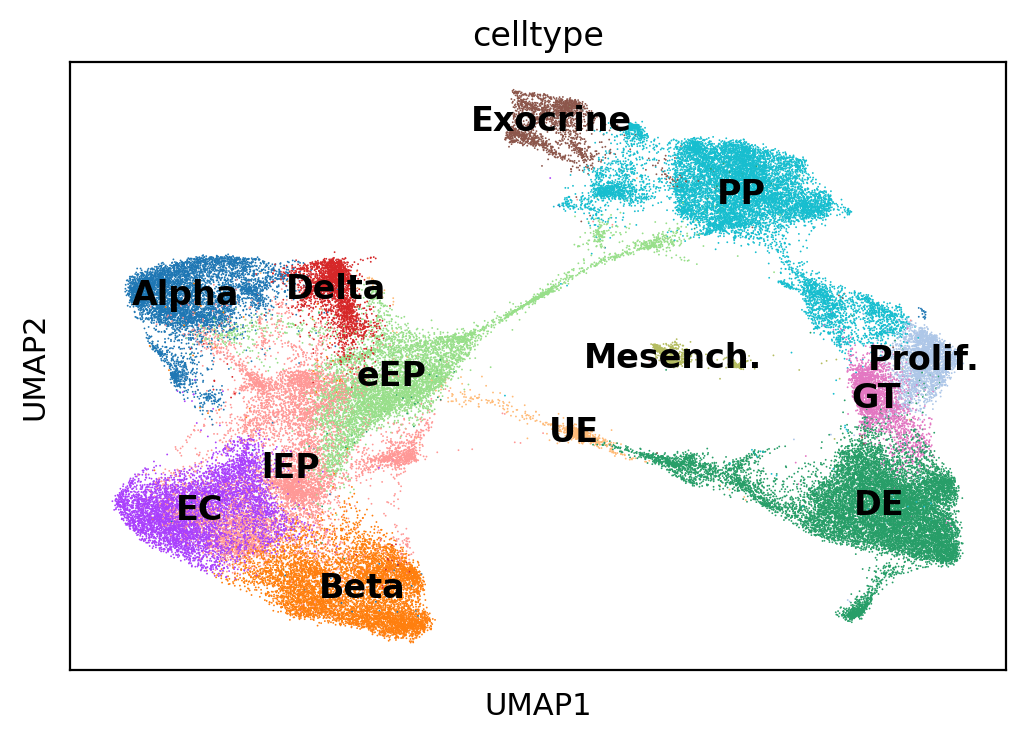

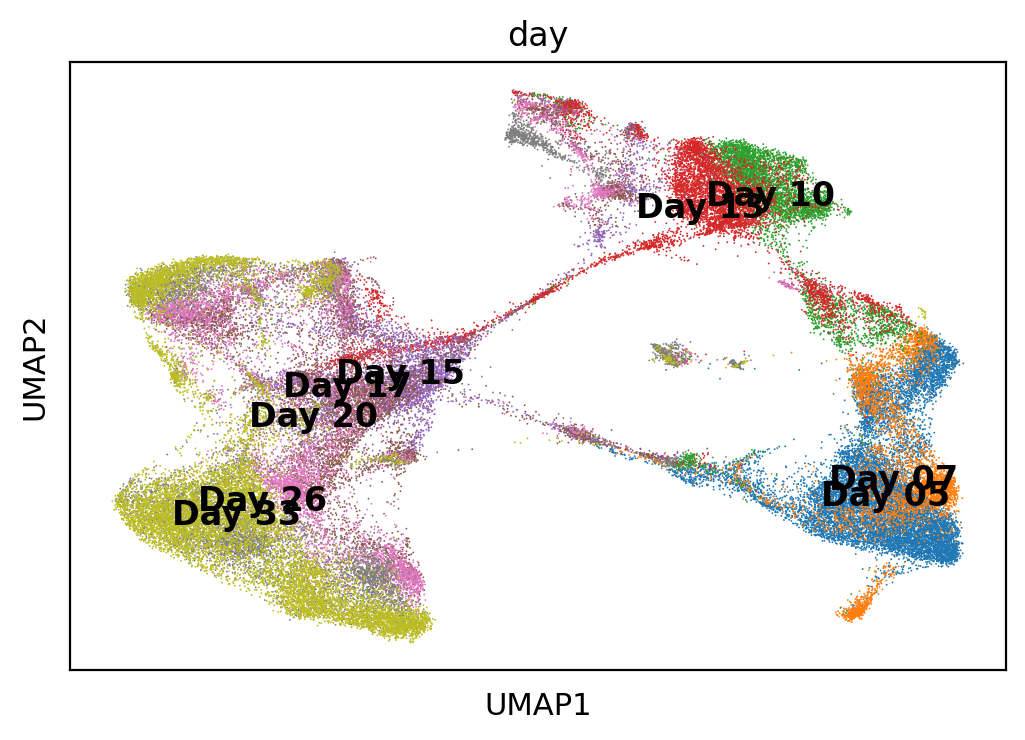

In [45]:
sc.pl.umap(adata_rna, color='celltype', legend_loc='on data')
sc.pl.umap(adata_rna, color='day', legend_loc='on data')


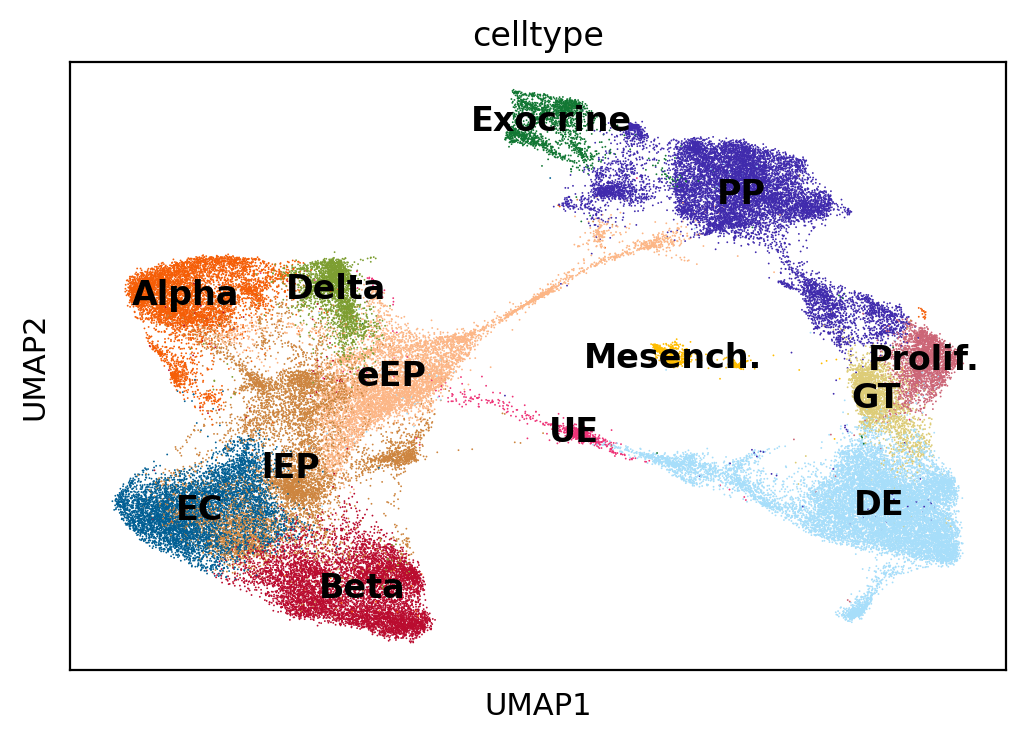

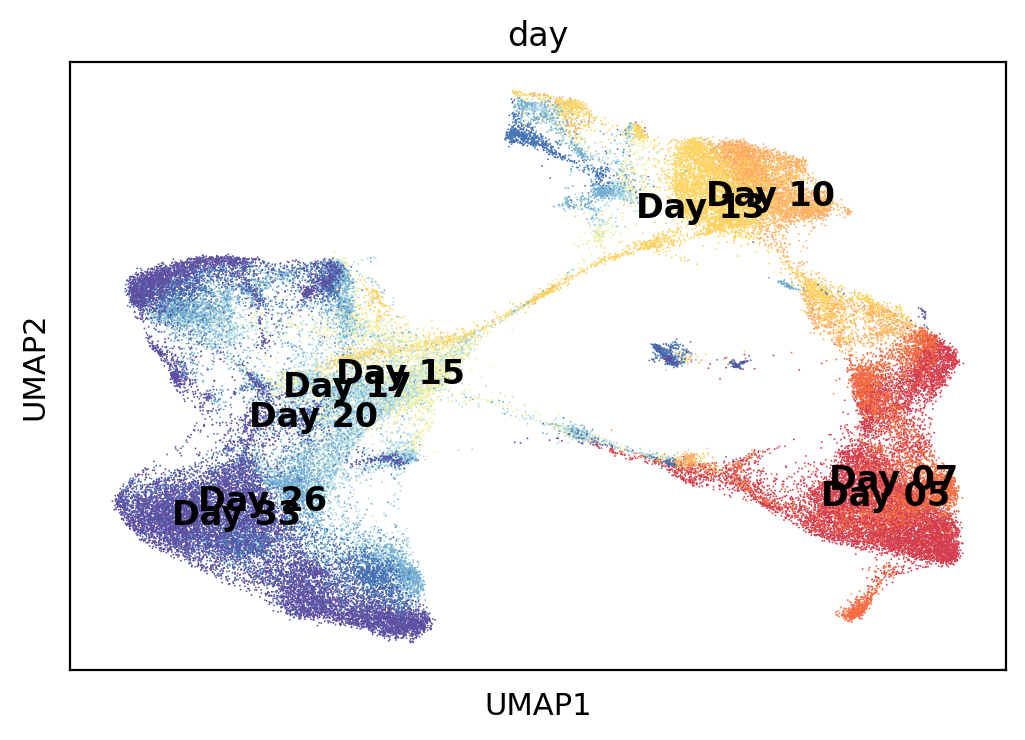

In [46]:
# ---------------------------
# 1) Cell type palette & order
# ---------------------------
pal_celltype = {
  "Mesench." : "#ffbd00",  # yellow
  "Prolif."  : "#CC6677", # dusty rose / muted red
  "DE"       : "#a7defa", # light sky blue
  "GT"       : "#DDCC77", # warm sand / golden khaki
  "PP"       : "#402bad", # deep indigo
  "Exocrine" : "#117733", # forest green
  "UE"       : "#EE3377", # magenta / raspberry
  "lEP"      : '#cd853f', #Peru color
  "eEP"      : "#fcb686", # light orange
  "EC"       : "#015f94", # royal blue
  "Beta"        : "#ba0c2f", # WashU red
  "Delta"        : "#7d9e31", # olive
  "Alpha"        : "#f55e07" # vivid orange
    }

celltype_order = list(pal_celltype.keys())

# ensure categorical with desired order (keep only categories present)
present_ct = [c for c in celltype_order if c in adata_rna.obs['celltype'].unique()]
adata_rna.obs['celltype'] = pd.Categorical(adata_rna.obs['celltype'],
                                           categories=present_ct, ordered=True)
adata_rna.uns['celltype_colors'] = [pal_celltype[c] for c in adata_rna.obs['celltype'].cat.categories]

# ---------------------------
# 2) Day palette & order
# ---------------------------
pal_day = {
    'Day 05':'#D53E4F',
    'Day 07':'#F46D43',
    'Day 10':'#FDAE61',
    'Day 13':'#fcd462',
    'Day 15':'#f0f0a8',
    'Day 17':'#ABD9E9',
    'Day 20':'#74ADD1',
    'Day 26':'#4575B4',
    'Day 33':'#5e4fa2'
}
day_order = list(pal_day.keys())

# (optional) standardize your day labels to the 'Day NN' format with leading zero
# If your current labels are like 'Day5', 'Day07', 5, etc., uncomment below:
# import re
# def norm_day(x):
#     s = str(x)
#     m = re.search(r'(\d+)', s)
#     return f"Day {int(m.group(1)):02d}" if m else s
# adata_rna.obs['day'] = adata_rna.obs['day'].map(norm_day)

present_days = [d for d in day_order if d in adata_rna.obs['day'].astype(str).unique()]
adata_rna.obs['day'] = pd.Categorical(adata_rna.obs['day'].astype(str),
                                      categories=present_days, ordered=True)
adata_rna.uns['day_colors'] = [pal_day[d] for d in adata_rna.obs['day'].cat.categories]

# ---------------------------
# 3) Plot (palettes are now automatic)
# ---------------------------
sc.pl.umap(adata_rna, color='celltype', legend_loc='on data')
sc.pl.umap(adata_rna, color='day',      legend_loc='on data')

In [47]:
assert adata_rna.n_obs == adata_atac.n_obs
adata_rna.obs_names = adata_atac.obs_names.copy()
adata_rna.obs_names


Index(['s2d1_AAACAGCCAAAGCGCA-1', 's2d1_AAACAGCCACATGCTA-1',
       's2d1_AAACAGCCAGCTAATT-1', 's2d1_AAACAGCCAGGACCTT-1',
       's2d1_AAACAGCCAGGCGATA-1', 's2d1_AAACAGCCAGGCTAAG-1',
       's2d1_AAACAGCCAGTAGCCT-1', 's2d1_AAACAGCCATGGAGGC-1',
       's2d1_AAACAGCCATTGCGAC-1', 's2d1_AAACATGCAATAGCCC-1',
       ...
       's6d14_TTTGTTGGTCCTCCAA-1', 's6d14_TTTGTTGGTGCAACTA-1',
       's6d14_TTTGTTGGTGGACATC-1', 's6d14_TTTGTTGGTGTTAGCA-1',
       's6d14_TTTGTTGGTTATCGAG-1', 's6d14_TTTGTTGGTTCATCTA-1',
       's6d14_TTTGTTGGTTGCCTCA-1', 's6d14_TTTGTTGGTTGTTGGA-1',
       's6d14_TTTGTTGGTTTACGTC-1', 's6d14_TTTGTTGGTTTGGGCG-1'],
      dtype='object', length=69535)

In [48]:
adata_atac.obs_names

Index(['s2d1_AAACAGCCAAAGCGCA-1', 's2d1_AAACAGCCACATGCTA-1',
       's2d1_AAACAGCCAGCTAATT-1', 's2d1_AAACAGCCAGGACCTT-1',
       's2d1_AAACAGCCAGGCGATA-1', 's2d1_AAACAGCCAGGCTAAG-1',
       's2d1_AAACAGCCAGTAGCCT-1', 's2d1_AAACAGCCATGGAGGC-1',
       's2d1_AAACAGCCATTGCGAC-1', 's2d1_AAACATGCAATAGCCC-1',
       ...
       's6d14_TTTGTTGGTCCTCCAA-1', 's6d14_TTTGTTGGTGCAACTA-1',
       's6d14_TTTGTTGGTGGACATC-1', 's6d14_TTTGTTGGTGTTAGCA-1',
       's6d14_TTTGTTGGTTATCGAG-1', 's6d14_TTTGTTGGTTCATCTA-1',
       's6d14_TTTGTTGGTTGCCTCA-1', 's6d14_TTTGTTGGTTGTTGGA-1',
       's6d14_TTTGTTGGTTTACGTC-1', 's6d14_TTTGTTGGTTTGGGCG-1'],
      dtype='object', length=69535)

In [53]:
# Save the result for use later on
adata_rna.write("checkpoints/MultiVelo/s2d1_s6d14_adata_rna_forMVelo_3860_GOI.h5ad")
adata_atac.write("checkpoints/MultiVelo/s2d1_s6d14_adata_atac_forMVelo_3860_GOI.h5ad")


In [54]:
# We reload in the raw data
adata_rna = sc.read_h5ad("checkpoints/MultiVelo/s2d1_s6d14_adata_rna_forMVelo_3860_GOI.h5ad")
adata_atac = sc.read_h5ad("checkpoints/MultiVelo/s2d1_s6d14_adata_atac_forMVelo_3860_GOI.h5ad")


In [55]:
adata_rna

AnnData object with n_obs × n_vars = 69535 × 3860
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'dataset', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA.weight', 'peaks.weight', 'wnn_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'merged_rna_clusters', 'cca_clusters', 'rpca_clusters', 'harmony_clusters', 'intjoint_clusters', 'nCount_integrated.peaks', 'nFeature_integrated.peaks', 'pseudotime', 'celltype', 'day', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'keep5500'
    uns: 'celltype_colors', 'day_colors', 'hvg', 'log1p', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [56]:
adata_atac

AnnData object with n_obs × n_vars = 69535 × 3860
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'dataset', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA.weight', 'peaks.weight', 'wnn_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'merged_rna_clusters', 'cca_clusters', 'rpca_clusters', 'harmony_clusters', 'intjoint_clusters', 'nCount_integrated.peaks', 'nFeature_integrated.peaks', 'pseudotime', 'celltype', 'day', 'n_counts'
    layers: 'Mc'
    obsp: 'connectivities'

In [ ]:
#I'd like that you're lonely, lonely like me. -broken by lovelytheband